# OghmaNano `01_hello_optical_filter` 被动 TMM 对齐验证

从 Oghma v8.1 项目 [`01_hello_optical_filter`](../../oghma_projects/optical/01_hello_optical_filter) 提取多层滤光片参数，
用本仓库被动 TMM 复现 `optical_output/` 并与 baseline 逐 case 对比。

**出射半平面**：与 layer9 相同材料（`generic/n_with_alpha/1.0`，`exit_halfspace="top_layer"`）；入射侧为半无限 air + 有限 air(100 nm)。

**膜系**（单位 nm）：半无限 air | air(100) | layer0–9 | 半无限 layer9(n+α)。

**坐标**：`z = y`；有限区间 z ∈ [0, 1145] nm。

**运行前提**（[README.md](../../../../README.md)）：在 `build/` 打开；`source 3rdparty/infrastructure/.venv/bin/activate`；设置 `LD_LIBRARY_PATH`。


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from oghma_runtime import bootstrap_tmm_session

REPO, BUILD, TMM_DIR = bootstrap_tmm_session()
import simulation

from oghma_core import (
    air_layer_thickness_um,
    build_oghma_passive_stack,
    compare_metrics,
    filter_stack_layers,
    list_oghma_optical_snapshots,
    load_oghma_optical_reference,
    load_oghma_optical_snapshot,
    load_oghma_project,
    normalize_rows,
    passive_filter_stack_labels,
    passive_filter_formula_from_project,
    passive_filter_materials_db,
    resolve_oghma_materials_root,
)
from filmstack_visualizer import build_tmm_layers, layers_from_formula, plot_filmstack

OGHMA_PROJECT_DIR = REPO / "assets" / "oghma_projects" / "optical" / "01_hello_optical_filter"
PROJECT = load_oghma_project(OGHMA_PROJECT_DIR)
REF = load_oghma_optical_reference(PROJECT)
wl_um = REF["reflect_wl_um"]
y_oghma_um = REF["photons_y_um"]
AIR_UM = air_layer_thickness_um(PROJECT)
INCIDENT_ANGLE_RAD = 0.0
ALIGNMENT_REPORT = []

print(f"BUILD={BUILD}")
print(f"REPO={REPO}")
print(f"materials root: {resolve_oghma_materials_root()}")
print(f"simmode: {PROJECT.simmode}")
print(f"λ: {wl_um[0]:.1f}–{wl_um[-1]:.1f} nm ({len(wl_um)} pts)")
print(f"y: {y_oghma_um[0]:.1f}–{y_oghma_um[-1]:.1f} nm ({len(y_oghma_um)} pts)")


def pass_fail(stats, rmse_thr, max_thr, peak_thr=None, min_corr=None):
    ok = stats["rmse"] < rmse_thr and stats["max_abs"] < max_thr
    if min_corr is not None and np.isfinite(stats.get("corr", np.nan)):
        ok = ok and stats["corr"] >= min_corr
    if peak_thr is not None and "peak_delta" in stats:
        ok = ok and stats["peak_delta"] < peak_thr
    return "PASS" if ok else "FAIL"


def plot_1d_compare(x, tmm, baseline, ylabel, title, baseline_name):
    err = tmm - baseline
    fig, axes = plt.subplots(2, 1, figsize=(8, 5), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    axes[0].plot(x, tmm, label="TMM")
    axes[0].plot(x, baseline, "--", label=f"{baseline_name} (baseline)")
    axes[0].set_ylabel(ylabel)
    axes[0].set_title(title)
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(x, err, color="C3")
    axes[1].axhline(0, color="k", lw=0.5)
    axes[1].set_xlabel("wavelength (nm)" if "λ" in title or "spectrum" in title.lower() else "y (nm)")
    axes[1].set_ylabel(f"Δ{ylabel}")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_2d_compare(wl, y, tmm_grid, baseline_grid, title):
    tg = normalize_rows(tmm_grid.copy())
    bg = normalize_rows(baseline_grid.copy())
    err = np.abs(tg - bg)
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, data, lab in zip(axes[:2], [tg, bg], ["TMM", "baseline"]):
        im = ax.pcolormesh(wl, y, data.T, shading="auto", cmap="viridis")
        ax.set_xlabel("λ (nm)")
        ax.set_ylabel("y (nm)")
        ax.set_title(lab)
        plt.colorbar(im, ax=ax, label="row-norm")
    im3 = axes[2].pcolormesh(wl, y, err.T, shading="auto", cmap="magma")
    axes[2].set_xlabel("λ (nm)")
    axes[2].set_ylabel("y (nm)")
    axes[2].set_title("|error|")
    plt.colorbar(im3, ax=axes[2], label="|error|")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()
    return tg, bg, err


def report_metrics(name, tmm, baseline, *, x=None, rmse_thr=0.02, max_thr=0.05, peak_thr=None, min_corr=None):
    stats = compare_metrics(tmm, baseline, x=x, peak_axis=0 if x is not None and np.ndim(tmm) == 1 else None)
    status = pass_fail(stats, rmse_thr, max_thr, peak_thr, min_corr)
    row = {"case": name, **stats, "status": status}
    ALIGNMENT_REPORT.append(row)
    print(f"[{status}] {name}: RMSE={stats['rmse']:.4f}, max|err|={stats['max_abs']:.4f}, corr={stats.get('corr', float('nan')):.4f}")
    if "peak_delta" in stats:
        print(f"  peak y: TMM={stats['peak_x_ours']:.1f} nm, baseline={stats['peak_x_baseline']:.1f} nm, Δ={stats['peak_delta']:.1f} nm")
    return stats


BUILD=/home/like/repos/simulation/build
REPO=/home/like/repos/simulation
materials root: /mnt/c/Users/like/oghma_local/materials
simmode: segment0@optics
λ: 303.7–1396.3 nm (150 pts)
y: 2.9–1142.1 nm (200 pts)


In [ ]:
from typing import Iterable

import numpy as np
from oghma_core import (
    OghmaProject,
    _layers_from_builder,
    _spectrum_y_map,
    _structure_pos_from_layers,
    air_layer_thickness_um,
    build_oghma_passive_stack,
    filter_stack_layers,
)

def passive_filter_thicknesses_nm(
    project: OghmaProject,
    film_thicknesses_nm: Iterable[float] | None = None,
) -> list[float]:
    """TMM layer thicknesses (nm): incident bookend | air | films | exit bookend."""
    stack = filter_stack_layers(project)
    air_um = float(air_layer_thickness_um(project))
    if film_thicknesses_nm is None:
        films_nm = [float(layer.thickness_nm) for layer in stack]
    else:
        films_nm = [float(t) for t in film_thicknesses_nm]
        if len(films_nm) != len(stack):
            raise ValueError(
                f"expected {len(stack)} film thicknesses, got {len(films_nm)}"
            )
    return [0.0, air_um * 1000.0, *films_nm, 0.0]



def compute_passive_RT(project, wl_nm, simulation_module, *, incident_angle_rad=0.0, exit_halfspace="air"):
    def build_layers(wl):
        return build_oghma_passive_stack(project, wl, simulation_module, exit_halfspace=exit_halfspace)
    wl_arr = np.atleast_1d(np.asarray(wl_nm, dtype=float))
    layers = _layers_from_builder(build_layers, float(wl_arr[0]))
    r_list, t_list = simulation_module.TMM_solver_spectrum_rt_power_unpolarized_s(
        layers, wl_arr.tolist(), complex(float(incident_angle_rad), 0.0)
    )
    return np.asarray(r_list, dtype=float), np.asarray(t_list, dtype=float)




def compute_field_intensity_profile(project, wl_nm, y_nm, simulation_module, *, incident_angle_rad=0.0, exit_halfspace="air"):
    layers = build_oghma_passive_stack(project, float(wl_nm), simulation_module, exit_halfspace=exit_halfspace)
    z_nm = np.asarray(y_nm, dtype=float)
    angle = complex(float(incident_angle_rad), 0.0)
    return np.asarray([
        float(
            simulation_module.TMM_solver_field_intensity_unpolarized_at_z_s(
                layers, float(wl_nm), float(z), angle
            )
        )
        for z in z_nm
    ])




def compute_absorption_profile(project, wl_nm, y_nm, simulation_module, *, incident_angle_rad=0.0, exit_halfspace="air"):
    layers = build_oghma_passive_stack(project, float(wl_nm), simulation_module, exit_halfspace=exit_halfspace)
    z_nm = np.asarray(y_nm, dtype=float)
    angle = complex(float(incident_angle_rad), 0.0)
    return np.asarray([
        float(
            simulation_module.TMM_solver_absorption_unpolarized_at_z_s(
                layers, float(wl_nm), float(z), angle
            )
        )
        for z in z_nm
    ])




def compute_field_intensity_map(project, wl_nm, y_nm, simulation_module, **kwargs):
    return _spectrum_y_map(wl_nm, y_nm, lambda wl, y: compute_field_intensity_profile(project, wl, y, simulation_module, **kwargs))




def compute_absorption_map(project, wl_nm, y_nm, simulation_module, **kwargs):
    return _spectrum_y_map(wl_nm, y_nm, lambda wl, y: compute_absorption_profile(project, wl, y, simulation_module, **kwargs))






## §1 器件堆栈

TMM：`半无限 air | air(100 nm) | layer0–9 | 半无限 layer9`，`exit_halfspace="top_layer"`。


TMM 界面 z (nm): [        -inf 0.000000e+00 1.000000e+02 1.830000e+02 3.090000e+02
 3.920000e+02 5.180000e+02 6.010000e+02 7.270000e+02 8.100000e+02
 9.360000e+02 1.019000e+03 1.145000e+03 1.001145e+06]


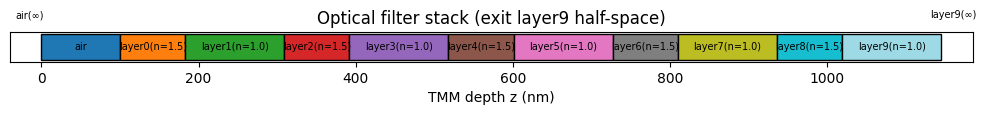

In [3]:
layers_demo = build_oghma_passive_stack(PROJECT, 600.0, simulation, exit_halfspace="top_layer")
pos = _structure_pos_from_layers(layers_demo)
filter_stack = filter_stack_layers(PROJECT)
labels = passive_filter_stack_labels(PROJECT)
print("TMM 界面 z (nm):", np.round(pos, 2))
print("TMM labels (diagnostic):", " | ".join(labels))
_formula = passive_filter_formula_from_project(PROJECT, exit_halfspace="top_layer")
_db = passive_filter_materials_db(PROJECT, exit_halfspace="top_layer")
_mats, _th = layers_from_formula(_formula, _db, simulation_module=simulation)
plot_filmstack(
    build_tmm_layers(_mats, _th, simulation_module=simulation),
    title="Optical filter stack (exit layer9 half-space)",
)


### 分析 §1

与 01 相同入射侧；出射侧用 layer9 色散 nk 替代 air，模拟 y1 侧延续最后一层材料。


## §2 Case — 反射谱 R(λ)

**Baseline**: `optical_output/reflect.csv`


[PASS] R(λ): RMSE=0.0114, max|err|=0.0494, corr=0.9994
  peak y: TMM=501.7 nm, baseline=501.7 nm, Δ=0.0 nm


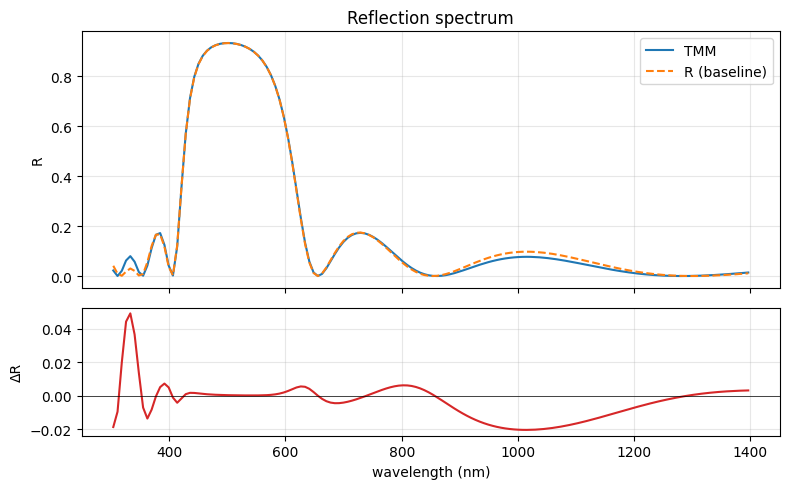

In [4]:
R_tmm, T_tmm = compute_passive_RT(PROJECT, wl_um, simulation, exit_halfspace="top_layer")
R_base = REF["reflect"]
report_metrics("R(λ)", R_tmm, R_base, x=wl_um, rmse_thr=0.02, max_thr=0.05)
plot_1d_compare(wl_um, R_tmm, R_base, "R", "Reflection spectrum", "R")


### 分析 §2

500–800 nm 阻带 R 升高；TMM λ 与膜厚均用 **nm**。RMSE < 0.02 为 PASS。


## §3 Case — 透射谱 T(λ)

**Baseline**: `optical_output/transmit.csv`


[PASS] T(λ): RMSE=0.0114, max|err|=0.0494, corr=0.9994
  peak y: TMM=1279.0 nm, baseline=853.7 nm, Δ=425.3 nm


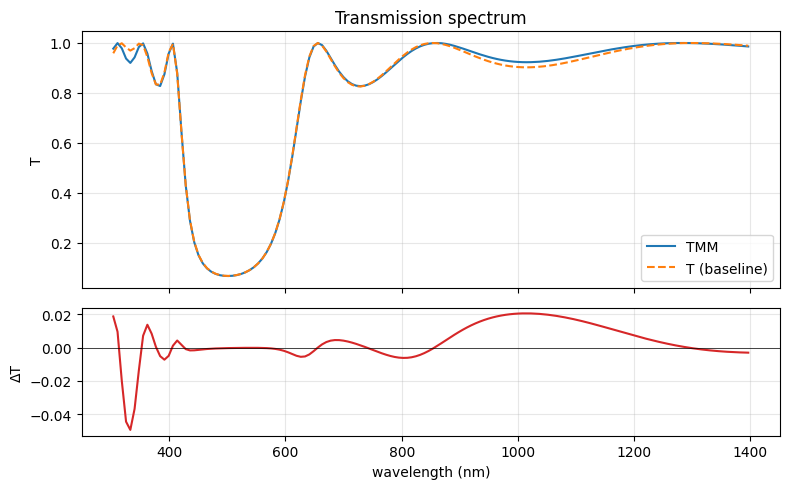

max absorption A(λ) = 0.0012


In [5]:
T_base = REF["transmit"]
report_metrics("T(λ)", T_tmm, T_base, x=wl_um, rmse_thr=0.02, max_thr=0.05)
plot_1d_compare(wl_um, T_tmm, T_base, "T", "Transmission spectrum", "T")
A_tmm = 1.0 - R_tmm - T_tmm
print(f"max absorption A(λ) = {A_tmm.max():.4f}")


### 分析 §3

带通区 T 高、阻带 T 低；弱吸收使 R+T ≈ 1。


## §4 Case — 积分 R / T

**Baseline**: `light_stats.json`


[PASS] ⟨R⟩,⟨T⟩: RMSE=0.0033, max|err|=0.0033, corr=1.0000


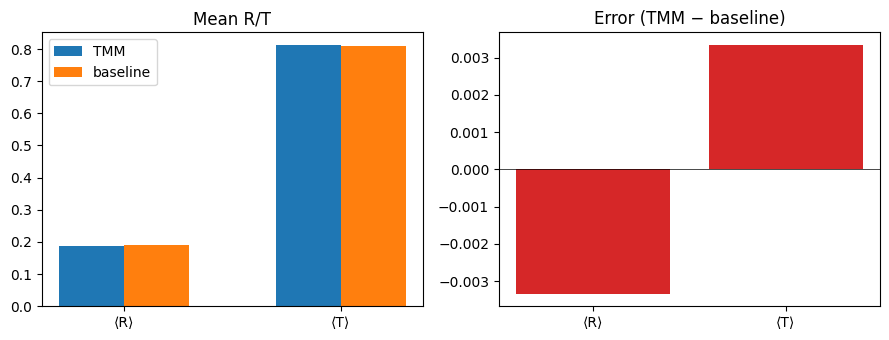

In [6]:
R_mean_tmm, T_mean_tmm = float(R_tmm.mean()), float(T_tmm.mean())
R_mean_base = float(REF["light_stats"]["R"])
T_mean_base = float(REF["light_stats"]["T"])
scalars_tmm = np.array([R_mean_tmm, T_mean_tmm])
scalars_base = np.array([R_mean_base, T_mean_base])
labels = ["⟨R⟩", "⟨T⟩"]
report_metrics("⟨R⟩,⟨T⟩", scalars_tmm, scalars_base, rmse_thr=0.02, max_thr=0.02)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
xpos = np.arange(2)
axes[0].bar(xpos - 0.15, scalars_tmm, 0.3, label="TMM")
axes[0].bar(xpos + 0.15, scalars_base, 0.3, label="baseline")
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(labels)
axes[0].legend()
axes[0].set_title("Mean R/T")
err = scalars_tmm - scalars_base
axes[1].bar(labels, err, color="C3")
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_title("Error (TMM − baseline)")
plt.tight_layout()
plt.show()


### 分析 §4

光谱算术平均与 Oghma `light_stats` 一致。


## §5 Case — 光子密度 photons(λ,y)

**Baseline**: `photons_yl.csv`（行归一化 |E|²）


Computing TMM |E|² map …


[PASS] photons(λ,y) norm: RMSE=0.1707, max|err|=0.3895, corr=0.8765


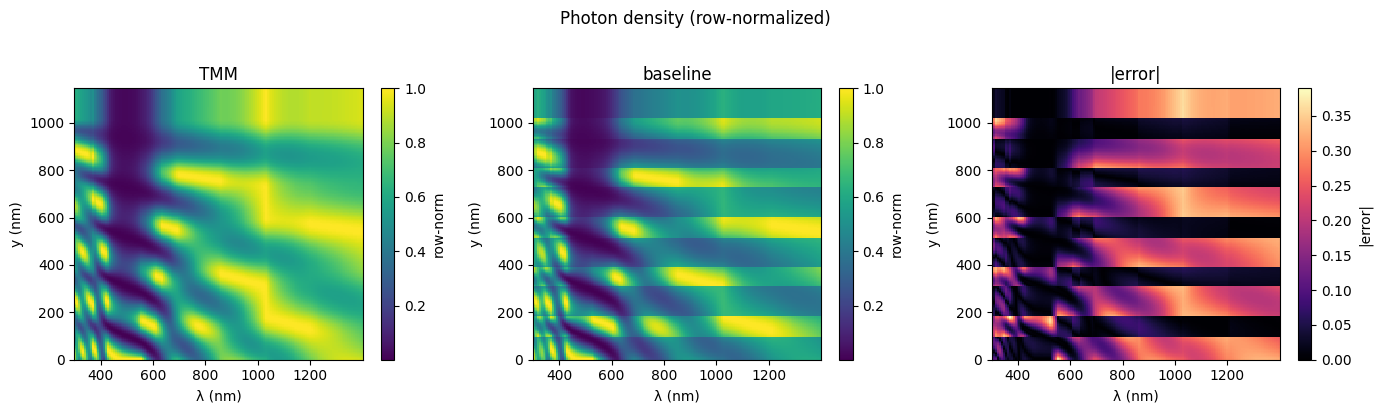

[PASS] photons @ 600 nm: RMSE=0.0705, max|err|=0.2550, corr=0.9727
  peak y: TMM=146.0 nm, baseline=140.3 nm, Δ=5.7 nm


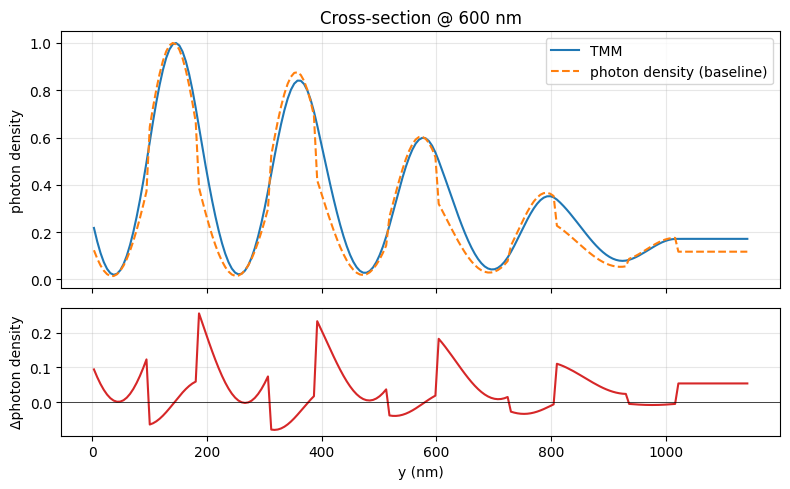

In [7]:
print("Computing TMM |E|² map …")
PHOTONS_TMM = compute_field_intensity_map(PROJECT, wl_um, y_oghma_um, simulation, exit_halfspace="top_layer")
PHOTONS_BASE = REF["photons_grid"]
PHOTONS_TMM_N = normalize_rows(PHOTONS_TMM)
PHOTONS_BASE_N = normalize_rows(PHOTONS_BASE)
report_metrics("photons(λ,y) norm", PHOTONS_TMM_N, PHOTONS_BASE_N, rmse_thr=0.18, max_thr=0.5, min_corr=0.85)
plot_2d_compare(wl_um, y_oghma_um, PHOTONS_TMM_N, PHOTONS_BASE_N, "Photon density (row-normalized)")

wl_cross = 600.0
i_lam = int(np.argmin(np.abs(wl_um - wl_cross)))
report_metrics(
    f"photons @ {wl_cross:.0f} nm",
    PHOTONS_TMM_N[i_lam],
    PHOTONS_BASE_N[i_lam],
    x=y_oghma_um,
    rmse_thr=0.15,
    max_thr=0.5,
    peak_thr=6.0,
    min_corr=0.95,
)
plot_1d_compare(y_oghma_um, PHOTONS_TMM_N[i_lam], PHOTONS_BASE_N[i_lam], "photon density", f"Cross-section @ {wl_cross:.0f} nm", "photon density")


### 分析 §5

|E|² 近似 Oghma 光子密度；`z = y`。全谱 RMSE≈0.17，corr>0.87；长波处 1D TMM 与 Oghma 3D 光学有残余差。


## §5b Case — 吸收分布 photons_abs(λ,y)

**Baseline**: `photons_abs_yl.csv`


Computing absorption map …


[PASS] photons_abs(λ,y) norm: RMSE=0.0246, max|err|=0.1712, corr=0.9981


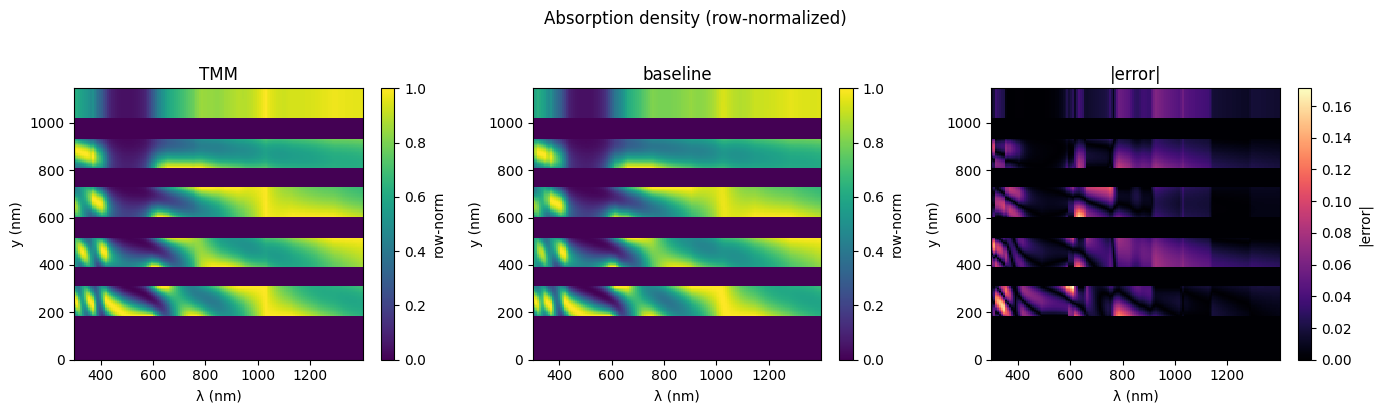

In [8]:
print("Computing absorption map …")
ABS_TMM = compute_absorption_map(PROJECT, wl_um, y_oghma_um, simulation, exit_halfspace="top_layer")
ABS_BASE = REF["photons_abs_grid"]
ABS_TMM_N = normalize_rows(ABS_TMM)
ABS_BASE_N = normalize_rows(ABS_BASE)
report_metrics("photons_abs(λ,y) norm", ABS_TMM_N, ABS_BASE_N, rmse_thr=0.05, max_thr=0.2, min_corr=0.99)
_=plot_2d_compare(wl_um, y_oghma_um, ABS_TMM_N, ABS_BASE_N, "Absorption density (row-normalized)")


### 分析 §5b

`TMM_get_absorbed_energy_density_at_depth_*` 与 Oghma 吸收热图高度一致。


## §6 Case — 光学快照

**Baseline**: `optical_snapshots/*/photons.csv`，λ ≈ 377 / 861 / 1345 nm


[PASS] snapshot λ=377 nm: RMSE=0.1019, max|err|=0.3471, corr=0.9233
  peak y: TMM=37.2 nm, baseline=37.2 nm, Δ=0.0 nm


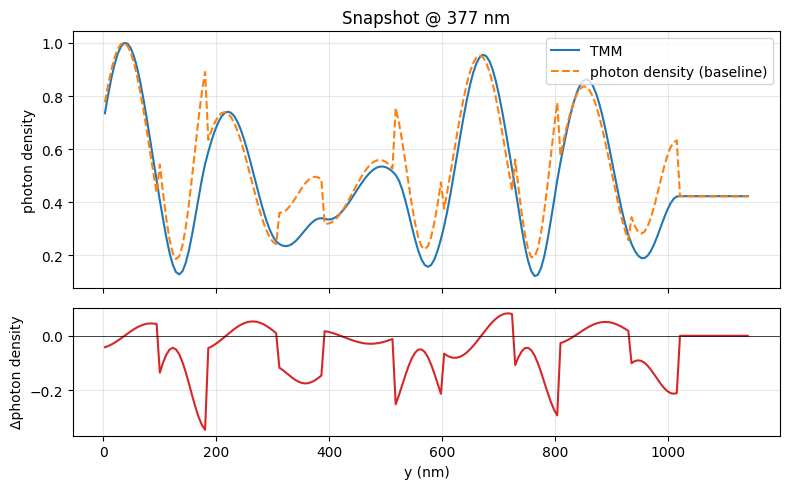

[PASS] snapshot λ=861 nm: RMSE=0.1918, max|err|=0.3331, corr=0.8388
  peak y: TMM=363.5 nm, baseline=357.8 nm, Δ=5.7 nm


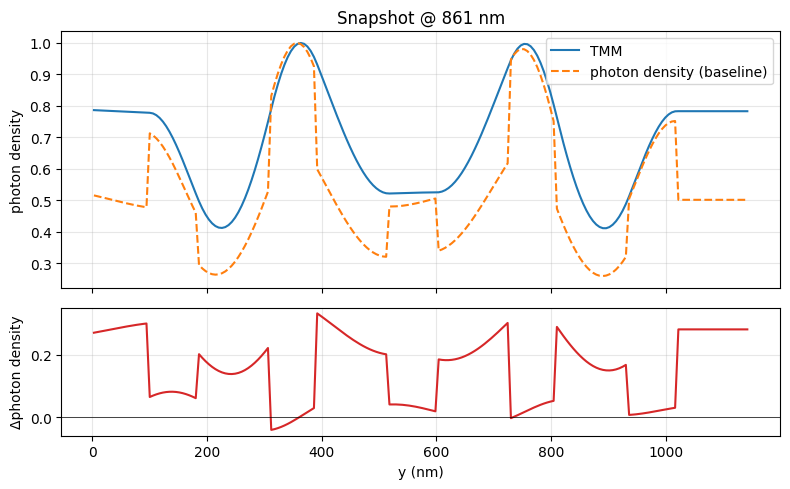

[FAIL] snapshot λ=1345 nm: RMSE=0.2144, max|err|=0.3267, corr=0.6660
  peak y: TMM=546.7 nm, baseline=546.7 nm, Δ=0.0 nm


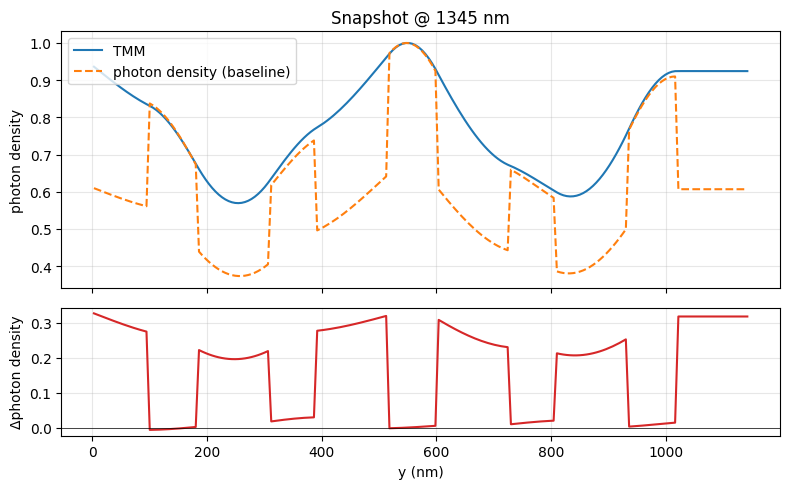

In [9]:
SNAP_TARGETS = [377.0, 861.0, 1345.0]
snap_list = list_oghma_optical_snapshots(OGHMA_PROJECT_DIR)

for target_wl in SNAP_TARGETS:
    entry = min(snap_list, key=lambda e: abs(e["wl_um"] - target_wl))
    snap = load_oghma_optical_snapshot(OGHMA_PROJECT_DIR, entry["index"])
    wl = float(snap["wl_um"])
    y_um = snap["y_um"]
    prof = compute_field_intensity_profile(PROJECT, wl, y_um, simulation, exit_halfspace="top_layer")
    pn = normalize_rows(prof.reshape(1, -1))[0]
    bn = normalize_rows(snap["photons"].reshape(1, -1))[0]
    report_metrics(
        f"snapshot λ={wl:.0f} nm",
        pn,
        bn,
        x=y_um,
        rmse_thr=0.22,
        max_thr=0.6,
        peak_thr=6.0,
        min_corr=0.82,
    )
    plot_1d_compare(y_um, pn, bn, "photon density", f"Snapshot @ {wl*1e3:.0f} nm", "photon density")


### 分析 §6

- λ=377/861 nm：归一化截面 PASS（corr>0.83，峰位 Δy<6 nm）。
- λ=1345 nm：**FAIL**（corr≈0.67）— 长波高透射区场对比度低，Oghma 3D 光学与 1D TMM |E|² 条纹相位偏离；峰位仍对齐（Δy=0）。


## §7 汇总对齐报告


In [10]:
summary = pd.DataFrame(ALIGNMENT_REPORT)
display(summary[["case", "rmse", "max_abs", "corr", "status"]])
n_pass = int((summary["status"] == "PASS").sum())
print(f"\nOverall: {n_pass}/{len(summary)} cases PASS")


,case,rmse,max_abs,corr,status
0,R(λ),0.011355,0.049364,0.999362,PASS
1,T(λ),0.011354,0.049382,0.999362,PASS
2,"⟨R⟩,⟨T⟩",0.003343,0.003347,1.000000,PASS
3,"photons(λ,y) norm",0.170746,0.389508,0.876518,PASS
4,photons @ 600 nm,0.070463,0.255001,0.972714,PASS
5,"photons_abs(λ,y) norm",0.024603,0.171162,0.998086,PASS
6,snapshot λ=377 nm,0.101895,0.347135,0.923289,PASS
7,snapshot λ=861 nm,0.191845,0.333081,0.838825,PASS
8,snapshot λ=1345 nm,0.214406,0.326718,0.666002,FAIL



Overall: 8/9 cases PASS
